In [1]:
%matplotlib notebook

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import scipy as sp
from scipy import sparse

from openTSNE import TSNE
from openTSNE import affinity, initialization, TSNEEmbedding
from openTSNE.affinity import Affinities

import time
import pickle

import memory_profiler
%load_ext memory_profiler

from src.connection import local_client as client

In [2]:
variables_path = "data/variables"
figures_path = "data/figures"
berenslab_data_path = "data/embeddings"

## Fetch training data from local open research

In [3]:
# fetch data
start_date = "2019-01-01"
end_date = "2021-12-31"

index_name = "frameintell_aux_minilmv6"

query = {
    "query": {"range": {"articleDate": {"gte": start_date, "lte": end_date}}}
}

data = client.search(
    body=query, index=index_name, size=10000, scroll="10m", pretty=True
)

articals = data["hits"]["hits"]

scroll_id = data["_scroll_id"]
scroll_size = len(data["hits"]["hits"])

while scroll_size > 0:
    print(scroll_id,scroll_size)
    data = client.scroll(scroll_id=scroll_id, scroll="10m")

    articals += data["hits"]["hits"]

    scroll_id = data["_scroll_id"]
    scroll_size = len(data["hits"]["hits"])

print(len(articals))
pubmed_ids = []
article_dates = []
embeddings = np.empty([len(articals), 384])
for i in range(len(articals)):
    pubmed_ids.append(articals[i]["_id"])
    article_dates.append(articals[i]["_source"]["articleDate"])
    embeddings[i] = articals[i]["_source"]["vector"]

# save embedding
np.save(os.path.join(berenslab_data_path, "pubmed_ids"), pubmed_ids)
np.save(os.path.join(berenslab_data_path, "article_dates"), article_dates)

FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFjNWZVFGd1hCVHVpRzFBRXI2U3BPU3cAAAAAAAAFoBZMMWVLRTJfblF4eXl4TzVoUnJvRUhn 10000
FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFjNWZVFGd1hCVHVpRzFBRXI2U3BPU3cAAAAAAAAFoBZMMWVLRTJfblF4eXl4TzVoUnJvRUhn 10000
FGluY2x1ZGVfY29udGV4dF91dWlkDXF1ZXJ5QW5kRmV0Y2gBFjNWZVFGd1hCVHVpRzFBRXI2U3BPU3cAAAAAAAAFoBZMMWVLRTJfblF4eXl4TzVoUnJvRUhn 1769
21769


# t-SNE

#### Affinities

In [4]:
%%capture cap

A = affinity.Uniform(  ## Affinities
    embeddings, k_neighbors=10, n_jobs=-1, verbose=1, random_state=42
)

In [5]:
with open(
    os.path.join(variables_path, "verbose_tsne_affinities.txt"), "w"
) as f:
    f.write(cap.stdout)

In [6]:
# save results
sp.sparse.save_npz(
    os.path.join(variables_path, "affinities_P_bert_reparsed"), A.P
)

In [7]:
# load affinities P
affinities_P_bert_reparsed = sp.sparse.load_npz(
    os.path.join(variables_path, "affinities_P_bert_reparsed.npz")
)

In [8]:
# create the affinities object

A = Affinities()
A.P = affinities_P_bert_reparsed

In [9]:
A.P

<21769x21769 sparse matrix of type '<class 'numpy.float64'>'
	with 328762 stored elements in Compressed Sparse Row format>

#### Initialization

In [10]:
%%time
%%memit

I = initialization.pca(embeddings, random_state=42)

np.save(os.path.join(variables_path, "initialization_bert_reparsed"), I)

peak memory: 712.33 MiB, increment: 57.70 MiB
CPU times: user 1.5 s, sys: 564 ms, total: 2.06 s
Wall time: 3.19 s


In [11]:
I = np.load(os.path.join(variables_path, "initialization_bert_reparsed.npy"))

#### Optimization

In [12]:
Zs = []
kls = []
n_iter = []


def mycallback(iteration, error, embedding):
    Zs.append(embedding.copy())
    kls.append(error)
    n_iter.append(iteration)

In [13]:
%%time

E = TSNEEmbedding(I, A, n_jobs=-1, random_state=42, verbose=True)

# early exaggeration
E = E.optimize(
    n_iter=125,
    exaggeration=12,
    momentum=0.5,
    n_jobs=-1,
    verbose=True,
    callbacks=mycallback,
    callbacks_every_iters=50,
)

# exaggeration annealing
exs = np.linspace(12, 1, 125)
for i in range(125):
    if (i + 1) % 50 == 0:
        E = E.optimize(
            n_iter=1,
            exaggeration=exs[i],
            momentum=0.8,
            n_jobs=-1,
            verbose=True,
            callbacks=mycallback,
            callbacks_every_iters=1,
        )

    else:
        E = E.optimize(
            n_iter=1,
            exaggeration=exs[i],
            momentum=0.8,
            n_jobs=-1,
            verbose=True,
        )

# final optimization without exaggeration
E = E.optimize(
    n_iter=1000,
    exaggeration=1,
    momentum=0.8,
    n_jobs=-1,
    verbose=True,
    callbacks=mycallback,
    callbacks_every_iters=50,
)

===> Running optimization with exaggeration=12.00, lr=1814.08 for 125 iterations...
Iteration   50, KL divergence 6.9362, 50 iterations in 2.4889 sec
Iteration  100, KL divergence 6.7275, 50 iterations in 1.8769 sec
   --> Time elapsed: 5.25 seconds
===> Running optimization with exaggeration=12.00, lr=1814.08 for 1 iterations...
   --> Time elapsed: 0.05 seconds
===> Running optimization with exaggeration=11.91, lr=1827.59 for 1 iterations...
   --> Time elapsed: 0.04 seconds
===> Running optimization with exaggeration=11.82, lr=1841.31 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=11.73, lr=1855.23 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=11.65, lr=1869.36 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=11.56, lr=1883.71 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=11.47, lr=

===> Running optimization with exaggeration=5.70, lr=3818.04 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=5.61, lr=3878.39 for 1 iterations...
   --> Time elapsed: 0.04 seconds
===> Running optimization with exaggeration=5.52, lr=3940.67 for 1 iterations...
   --> Time elapsed: 0.04 seconds
===> Running optimization with exaggeration=5.44, lr=4004.98 for 1 iterations...
   --> Time elapsed: 0.04 seconds
===> Running optimization with exaggeration=5.35, lr=4071.43 for 1 iterations...
   --> Time elapsed: 0.04 seconds
===> Running optimization with exaggeration=5.26, lr=4140.12 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=5.17, lr=4211.16 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=5.08, lr=4284.69 for 1 iterations...
   --> Time elapsed: 0.03 seconds
===> Running optimization with exaggeration=4.99, lr=4360.83 for 1 iterations...

In [14]:
with open(os.path.join(variables_path, "verbose_tsne_reparsed.txt"), "w") as f:
    f.write(cap.stdout)

In [15]:
Zs_array = []
for i in np.arange(len(Zs)):
    Zs_array.append(np.array(Zs[i]))

In [16]:
# save results
f = open(os.path.join(variables_path, "Zs_array_reparsed.pkl"), "wb")
pickle.dump(Zs_array, f)
f.close()

In [17]:
# save iter
f = open(os.path.join(variables_path, "iterations_reparsed.pkl"), "wb")
pickle.dump(n_iter, f)
f.close()

In [18]:
# save kl divergence
f = open(os.path.join(variables_path, "kl_divergence_reparsed.pkl"), "wb")
pickle.dump(kls, f)
f.close()

In [19]:
tsne = np.array(E)

# save
np.save(os.path.join(variables_path, "tsne_reparsed"), tsne)

#### Plot

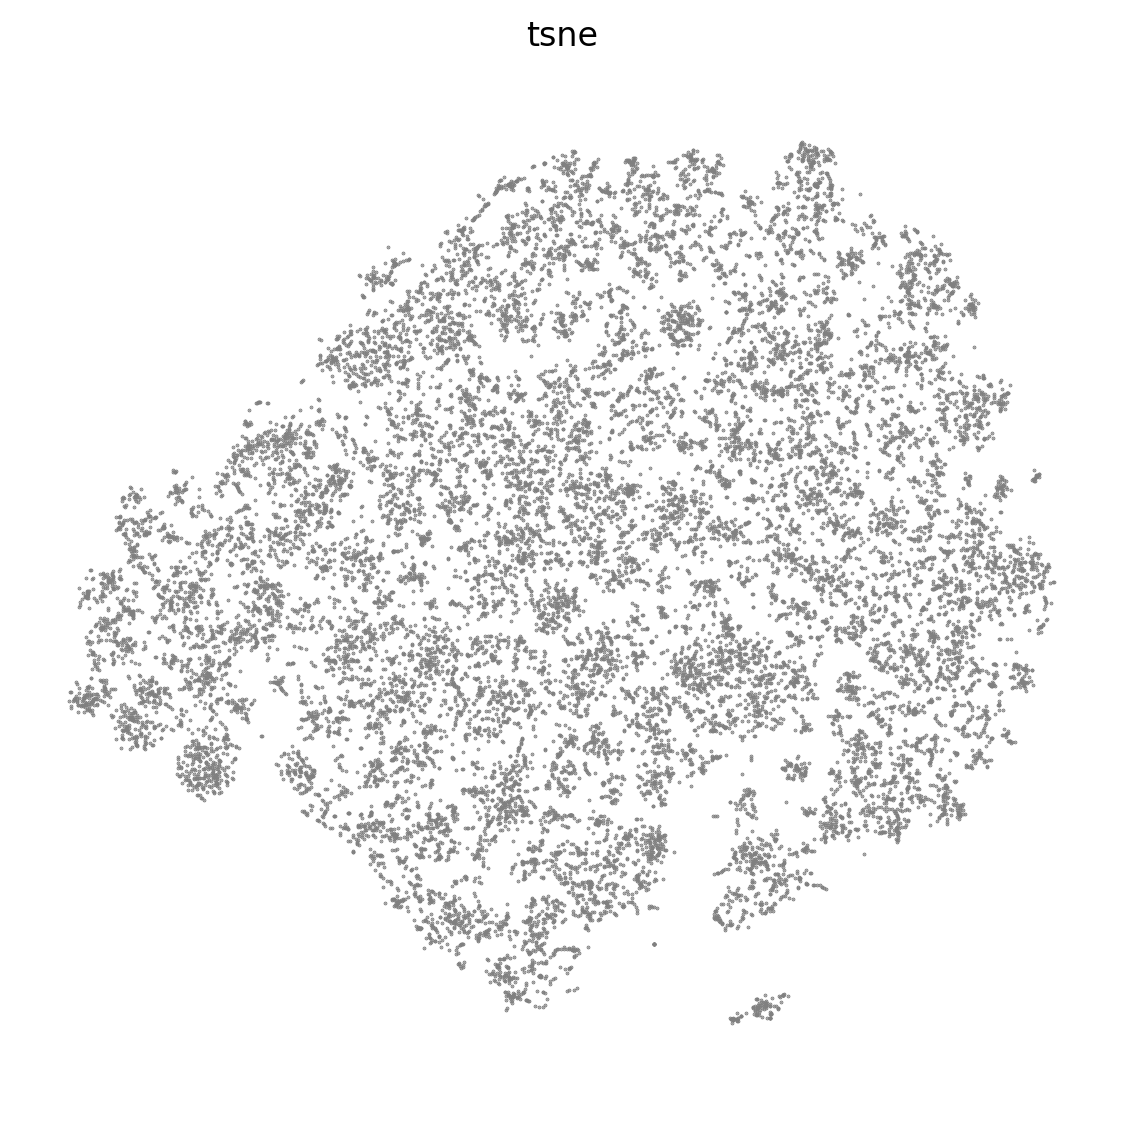

In [20]:
%matplotlib inline
# tsne = np.load(os.path.join(variables_path, "tsne_reparsed.npy"))
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=200, layout="constrained")

ax.scatter(
    tsne[:, 0],
    tsne[:, 1],
    s=0.5,
    c="grey",
    marker=".",
)
ax.set_title("tsne")
ax.axis("equal")
ax.grid()
ax.axis("off")
plt.show()

fig.savefig('data/results/tsne.png')